Dataset successfully loaded.
Dataset Size: 200
   age  sex  cp    trestbps        chol  fbs  restecg     thalach  exang  \
0   66    1   3  167.083933  227.544226    1        2  161.511521      0   
1   55    1   2  165.027957  260.030511    1        2  105.561616      1   
2   62    1   2  142.227338  228.690914    1        2  113.251117      1   
3   36    1   3  120.642025  238.484031    1        0  154.031149      0   
4   37    0   2  142.682087  194.224846    0        2  151.425246      1   

    oldpeak  slope  ca  thal  target  
0  2.424789      0   0     1       1  
1  1.286288      1   3     2       1  
2  2.090486      1   2     2       1  
3  3.365221      2   1     2       1  
4  1.589874      2   1     2       1  
Best Parameters found by GridSearchCV for KNN:
{'model__metric': 'manhattan', 'model__n_neighbors': 7, 'model__weights': 'distance'}
KNN Performance:
Confusion Matrix:
 [[20  4]
 [ 8 16]]
F1 Score: 0.7272727272727273
Accuracy Score: 0.75
Classification Report:
 

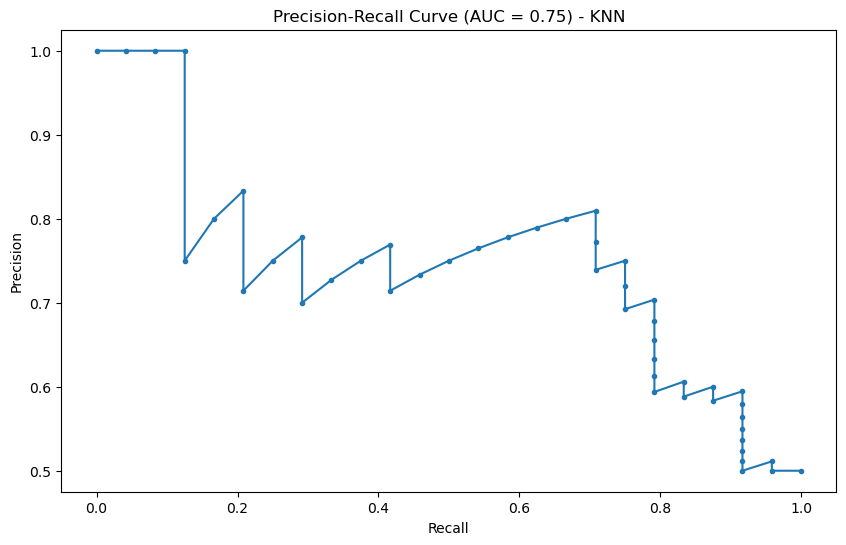

Best Parameters found by GridSearchCV for Random Forest:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Random Forest Performance:
Confusion Matrix:
 [[17  7]
 [11 13]]
F1 Score: 0.5909090909090909
Accuracy Score: 0.625
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.71      0.65        24
           1       0.65      0.54      0.59        24

    accuracy                           0.62        48
   macro avg       0.63      0.62      0.62        48
weighted avg       0.63      0.62      0.62        48

ROC AUC Score: 0.6927083333333334


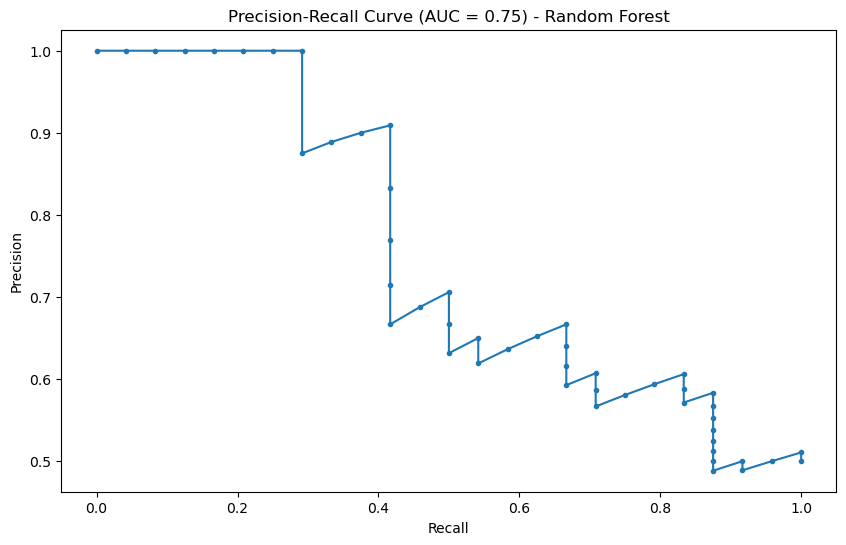

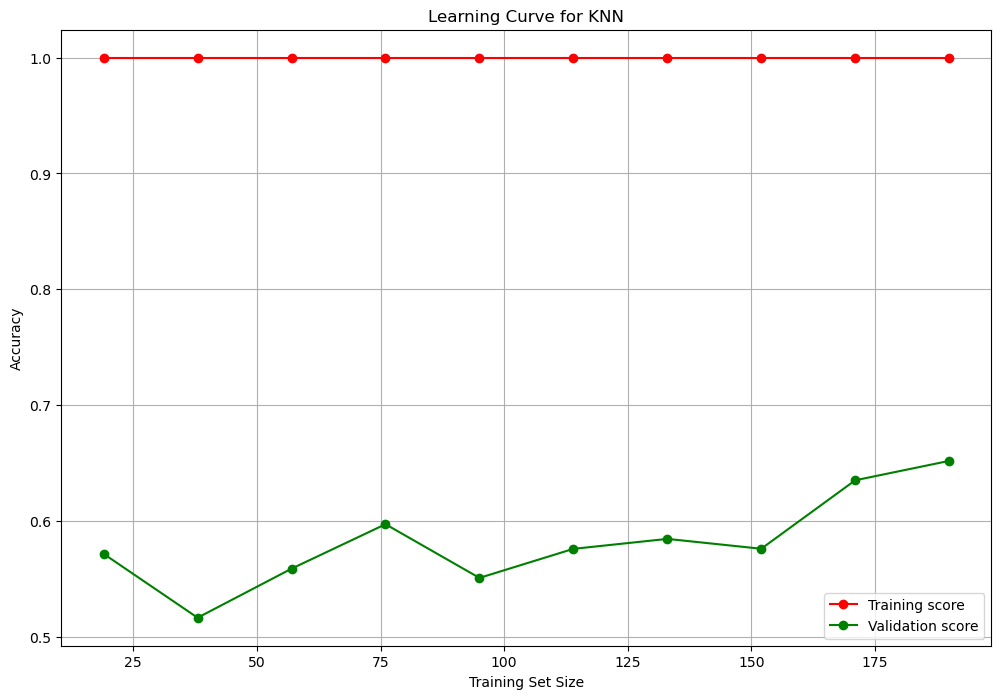

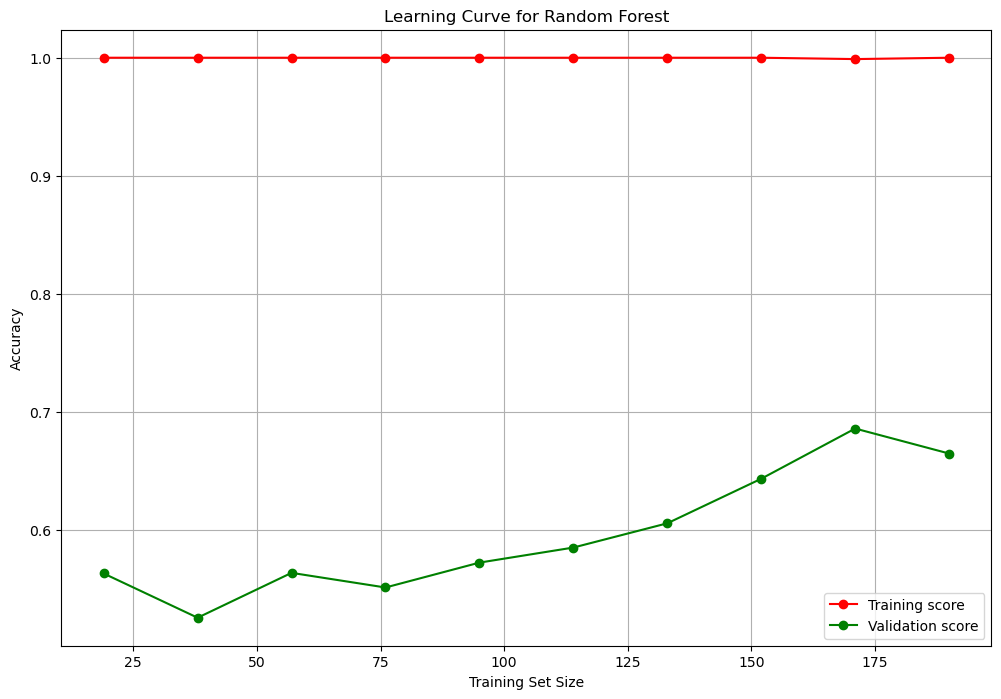

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImPipeline
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Load the dataset with error handling
try:
    large_df = pd.read_csv("C:/Users/adams/Downloads/large_heart_disease.csv")
    print("Dataset successfully loaded.")
except FileNotFoundError as e:
    print(f"Error: {e}")
    raise

# Convert age values to integer data type
large_df["age"] = large_df["age"].astype(int)

# Save the modified dataset
large_df.to_csv("modified_large_heart_disease.csv", index=False)

# Output the size and first rows of the dataset
print(f"Dataset Size: {len(large_df)}")
print(large_df.head())

# Split features and target
X = large_df.iloc[:, 0:8]
y = large_df.iloc[:, 8]

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=0)
X, y = smote.fit_resample(X, y)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2, stratify=y)

# Feature Scaling
scaler = MinMaxScaler()

# Feature Engineering: Adding polynomial features and interaction terms
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)

# PCA for dimensionality reduction
pca = PCA(n_components=0.95)

# Feature Selection
feature_selector = SelectKBest(score_func=f_classif, k=10)  # Select top 10 features

# K-Nearest Neighbors Classifier
knn = KNeighborsClassifier()

# Create a pipeline for KNN
pipeline_knn = SkPipeline([
    ('scaling', scaler),
    ('polynomial_features', poly),
    ('pca', pca),
    ('feature_selection', feature_selector),
    ('model', knn)
])

# Parameter Grid for KNN
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan'],
}

# Grid Search with Cross-Validation for KNN
grid_search_knn = GridSearchCV(estimator=pipeline_knn, param_grid=param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_knn.fit(X_train, y_train)

# Best KNN model
print("Best Parameters found by GridSearchCV for KNN:")
print(grid_search_knn.best_params_)
best_knn_pipeline = grid_search_knn.best_estimator_

# Evaluate KNN
y_pred_knn = best_knn_pipeline.predict(X_test)
y_pred_knn_proba = best_knn_pipeline.predict_proba(X_test)[:, 1]

# KNN Performance
print("KNN Performance:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("Accuracy Score:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
if len(np.unique(y)) == 2:
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_knn_proba))

# Precision-Recall Curve for KNN
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_pred_knn_proba)
pr_auc_knn = auc(recall_knn, precision_knn)
plt.figure(figsize=(10, 6))
plt.plot(recall_knn, precision_knn, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AUC = {pr_auc_knn:.2f}) - KNN')
plt.show()

# Random Forest Classifier
rf = RandomForestClassifier(random_state=0)

# Create a pipeline for Random Forest
pipeline_rf = SkPipeline([
    ('scaling', scaler),
    ('polynomial_features', poly),
    ('pca', pca),
    ('feature_selection', feature_selector),
    ('model', rf)
])

# Parameter Grid for Random Forest
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
}

# Grid Search with Cross-Validation for Random Forest
grid_search_rf = GridSearchCV(estimator=pipeline_rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Best Random Forest model
print("Best Parameters found by GridSearchCV for Random Forest:")
print(grid_search_rf.best_params_)
best_rf_pipeline = grid_search_rf.best_estimator_

# Evaluate Random Forest
y_pred_rf = best_rf_pipeline.predict(X_test)
y_pred_rf_proba = best_rf_pipeline.predict_proba(X_test)[:, 1]

# Random Forest Performance
print("Random Forest Performance:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
if len(np.unique(y)) == 2:
    print("ROC AUC Score:", roc_auc_score(y_test, y_pred_rf_proba))

# Precision-Recall Curve for Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_rf_proba)
pr_auc_rf = auc(recall_rf, precision_rf)
plt.figure(figsize=(10, 6))
plt.plot(recall_rf, precision_rf, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AUC = {pr_auc_rf:.2f}) - Random Forest')
plt.show()

# Function for plotting learning curves
def plot_learning_curve(pipeline, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    plt.figure(figsize=(12, 8))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Validation score')
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid()
    plt.show()

# Plot learning curves for KNN
plot_learning_curve(best_knn_pipeline, X, y, 'Learning Curve for KNN')

# Plot learning curves for Random Forest
plot_learning_curve(best_rf_pipeline, X, y, 'Learning Curve for Random Forest')